<a href="https://colab.research.google.com/github/ajsarsva/video-captioning-thesis/blob/main/notebooks/day21_qualitative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Master cell

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('/content/drive/MyDrive/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

if os.path.exists('/content/video-captioning-thesis'):
    %cd /content/video-captioning-thesis
    !git pull origin main
else:
    !git clone https://github.com/ajsarsva/video-captioning-thesis.git
    %cd /content/video-captioning-thesis

import sys
sys.path.append('/content/video-captioning-thesis/src')

print("✅ Ready!")

Mounted at /content/drive
Cloning into 'video-captioning-thesis'...
remote: Enumerating objects: 105, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 105 (delta 56), reused 27 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (105/105), 16.98 MiB | 7.35 MiB/s, done.
Resolving deltas: 100% (56/56), done.
/content/video-captioning-thesis
✅ Ready!


In [2]:
import json, os, sys
sys.path.append('/content/video-captioning-thesis/src')

# Load all results
with open('/content/drive/MyDrive/thesis-data/MSR_VTT.json') as f:
    gt_data = json.load(f)
with open('/content/drive/MyDrive/thesis-data/captions/strategy_A_full.json') as f:
    results_a = json.load(f)
with open('/content/drive/MyDrive/thesis-data/captions/strategy_B_full.json') as f:
    results_b = json.load(f)
with open('/content/drive/MyDrive/thesis-data/captions/strategy_C_full.json') as f:
    results_c = json.load(f)

# Build ground truth lookup
ground_truth = {}
for ann in gt_data['annotations']:
    vid = ann['image_id']
    if vid not in ground_truth:
        ground_truth[vid] = []
    ground_truth[vid].append(ann['caption'])

print("All data loaded!")

All data loaded!


In [4]:
!pip install pycocoevalcap pycocotools -q
!pip install nltk -q

import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("✅ Evaluation libraries ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 8.7 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ Evaluation libraries ready!


Videos Where Strategies Differ Most

In [5]:
from pycocoevalcap.cider.cider import Cider

# Compute per-video CIDEr scores for each strategy
def get_per_video_cider(results, ground_truth):
    """Get CIDEr score for each individual video."""
    cider_scorer = Cider()
    per_video_scores = {}

    for vid in results:
        if vid not in ground_truth:
            continue
        if not results[vid]['caption'].strip():
            continue

        gt = {vid: ground_truth[vid]}
        hyp = {vid: [results[vid]['caption']]}

        try:
            score, _ = cider_scorer.compute_score(gt, hyp)
            per_video_scores[vid] = score
        except:
            per_video_scores[vid] = 0.0

    return per_video_scores

print("Computing per-video CIDEr scores...")
print("This may take a few minutes...")

cider_a = get_per_video_cider(results_a, ground_truth)
cider_b = get_per_video_cider(results_b, ground_truth)
cider_c = get_per_video_cider(results_c, ground_truth)

print(f"Done! Computed scores for {len(cider_a)} videos")

Computing per-video CIDEr scores...
This may take a few minutes...
Done! Computed scores for 7010 videos


Best Qualitative Examples

In [12]:
def is_good_caption(caption):
    words = caption.lower().split()

    # Too short
    if len(words) < 5:
        return False

    # Repetition check
    from collections import Counter
    word_counts = Counter(words)
    if max(word_counts.values()) > 2:
        return False

    # Contains website/brand spam words
    spam_words = ['xbox', 'thor', 'godzilla', 'transformers',
                  'injustice', 'vampire', 'avengers', 'subre',
                  'wwe', 'undertaker', 'logo', 'text', 'screen reads',
                  'episode', 'season', 'trailer', 'movie', 'watch']
    caption_lower = caption.lower()
    if any(word in caption_lower for word in spam_words):
        return False

    return True

# Also check against ground truth — good example = at least one ref caption
# shares words with generated caption
def has_relevant_ground_truth(vid, cap_a, ground_truth):
    refs = ground_truth.get(vid, [])
    if not refs:
        return False
    # Check if any reference shares at least 2 words with Strategy A caption
    cap_words = set(cap_a.lower().split())
    for ref in refs:
        ref_words = set(ref.lower().split())
        if len(cap_words & ref_words) >= 2:
            return True
    return False

# Re-filter with stricter criteria
best_examples = []

for vid, diff, ca, cb, cc in interesting:
    if (is_good_caption(ca) and
        is_good_caption(cb) and
        is_good_caption(cc) and
        has_relevant_ground_truth(vid, ca, ground_truth)):
        best_examples.append((vid, diff, ca, cb, cc))

print(f"High quality examples found: {len(best_examples)}")
print("\nTop 10:")
print("=" * 80)
for vid, diff, ca, cb, cc in best_examples[:10]:
    refs = ground_truth[vid][:2]
    print(f"\n{vid} (difference: {diff:.3f})")
    print(f"  A: {ca}")
    print(f"  B: {cb}")
    print(f"  C: {cc}")
    print(f"  REF1: {refs[0]}")
    print(f"  REF2: {refs[1]}")

High quality examples found: 2401

Top 10:

video4633 (difference: 0.958)
  A: a collection of glass pieces
  B: a black background with a white and red flower
  C: people ' s choice awards
  REF1: a man is looking at something
  REF2: a man is wearing a black t-shirt

video4889 (difference: 0.958)
  A: two men are dancing in the street
  B: a woman sitting on a bench
  C: a man standing next to a green trash bin
  REF1: a man defends himself from attackers in the park
  REF2: a man is holding a case

video5896 (difference: 0.958)
  A: the dark knight in batman returns
  B: a man is pointing his finger at another man
  C: a black background with a white and red light
  REF1: a girl is riding with her arms spread out into the air
  REF2: a girls is feels to fly

video4430 (difference: 0.944)
  A: the little mermaid and her cat are talking to each other people
  B: a cartoon character in a pink outfit
  C: the adventures of sherlock and mr toad
  REF1: a cartoon character is preparing so

In [13]:
# Manually selected best examples
selected_videos = ['video4889', 'video6285', 'video0',
                   'video5521', 'video4381', 'video4430']

# Print their full details including more reference captions
for vid in selected_videos:
    ca = results_a[vid]['caption']
    cb = results_b[vid]['caption']
    cc = results_c[vid]['caption']
    refs = ground_truth[vid][:5]

    print(f"\n{'='*60}")
    print(f"VIDEO: {vid}")
    print(f"  A (Uniform):    {ca}")
    print(f"  B (SSIM):       {cb}")
    print(f"  C (CLIP):       {cc}")
    print(f"  References:")
    for i, r in enumerate(refs):
        print(f"    {i+1}. {r}")


VIDEO: video4889
  A (Uniform):    two men are dancing in the street
  B (SSIM):       a woman sitting on a bench
  C (CLIP):       a man standing next to a green trash bin
  References:
    1. a man defends himself from attackers in the park
    2. a man is holding a case
    3. a music video with the foo fighters
    4. about a music and action
    5. dave grohl performs in a music video

VIDEO: video6285
  A (Uniform):    a computer screen with a cartoon character on it
  B (SSIM):       a video game with a room filled with different items
  C (CLIP):       pep goes to the rescue screenshot
  References:
    1. a children s computer game is shown
    2. a frozen screenshot of cartoon pigs in a room
    3. a game based on peppa pig is being played
    4. a game is being played
    5. a girl s game is shown

VIDEO: video0
  A (Uniform):    a road with a sign on it
  B (SSIM):       a car driving down a road at night
  C (CLIP):       audi q q spotted in the wild
  References:
    1. 

Qualitative Figure for Each Selected Video

In [14]:
selected_videos = ['video0', 'video6285', 'video4430', 'video5521']

Processing video0...


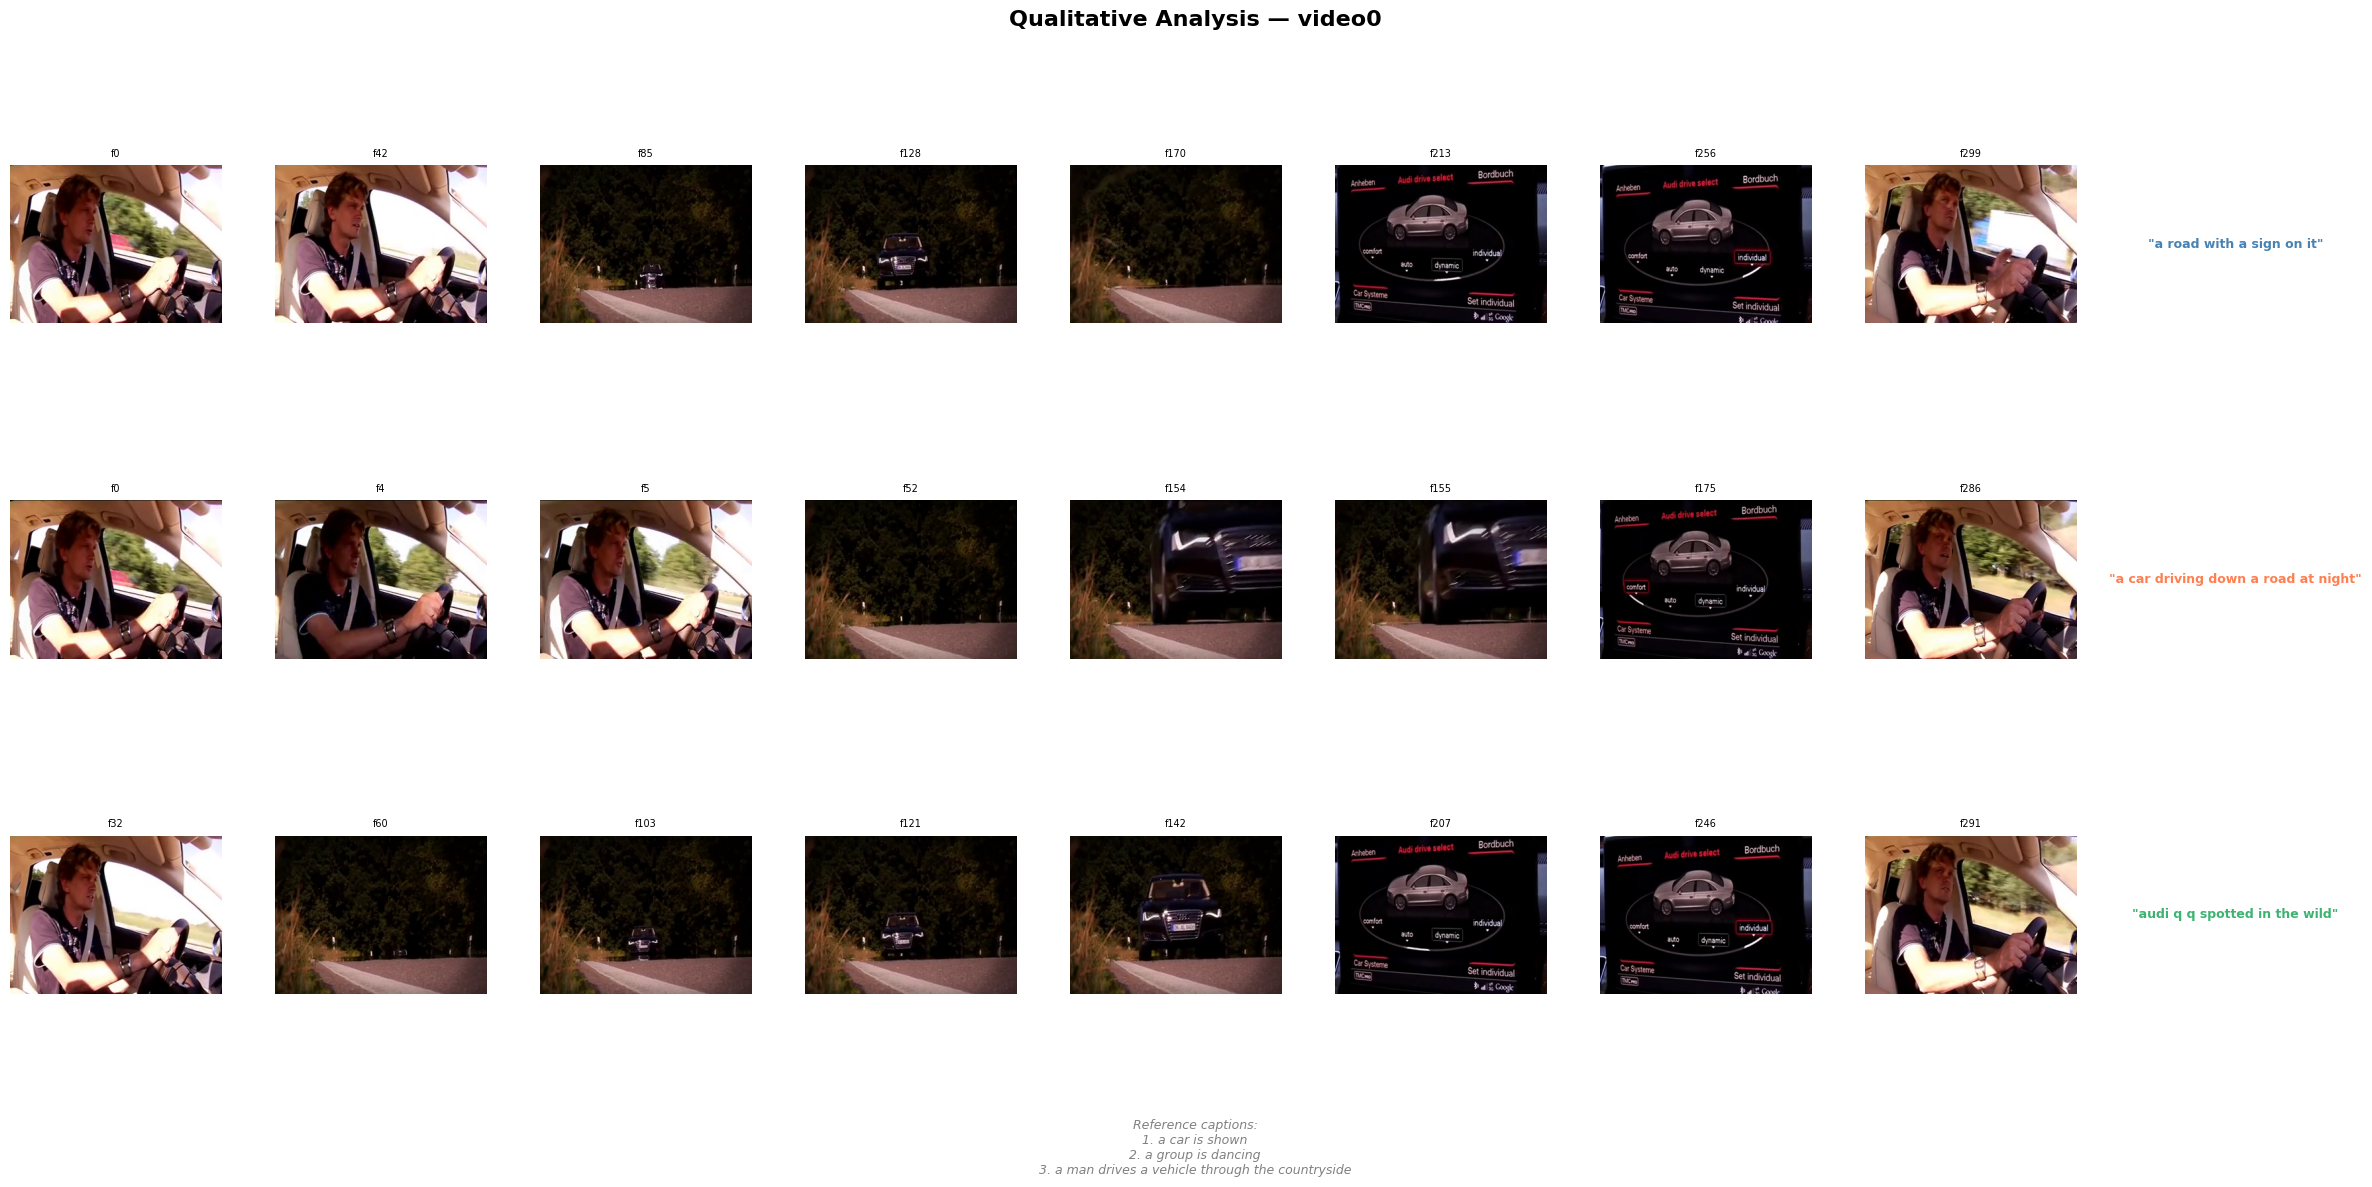

✅ video0 saved!
Processing video6285...


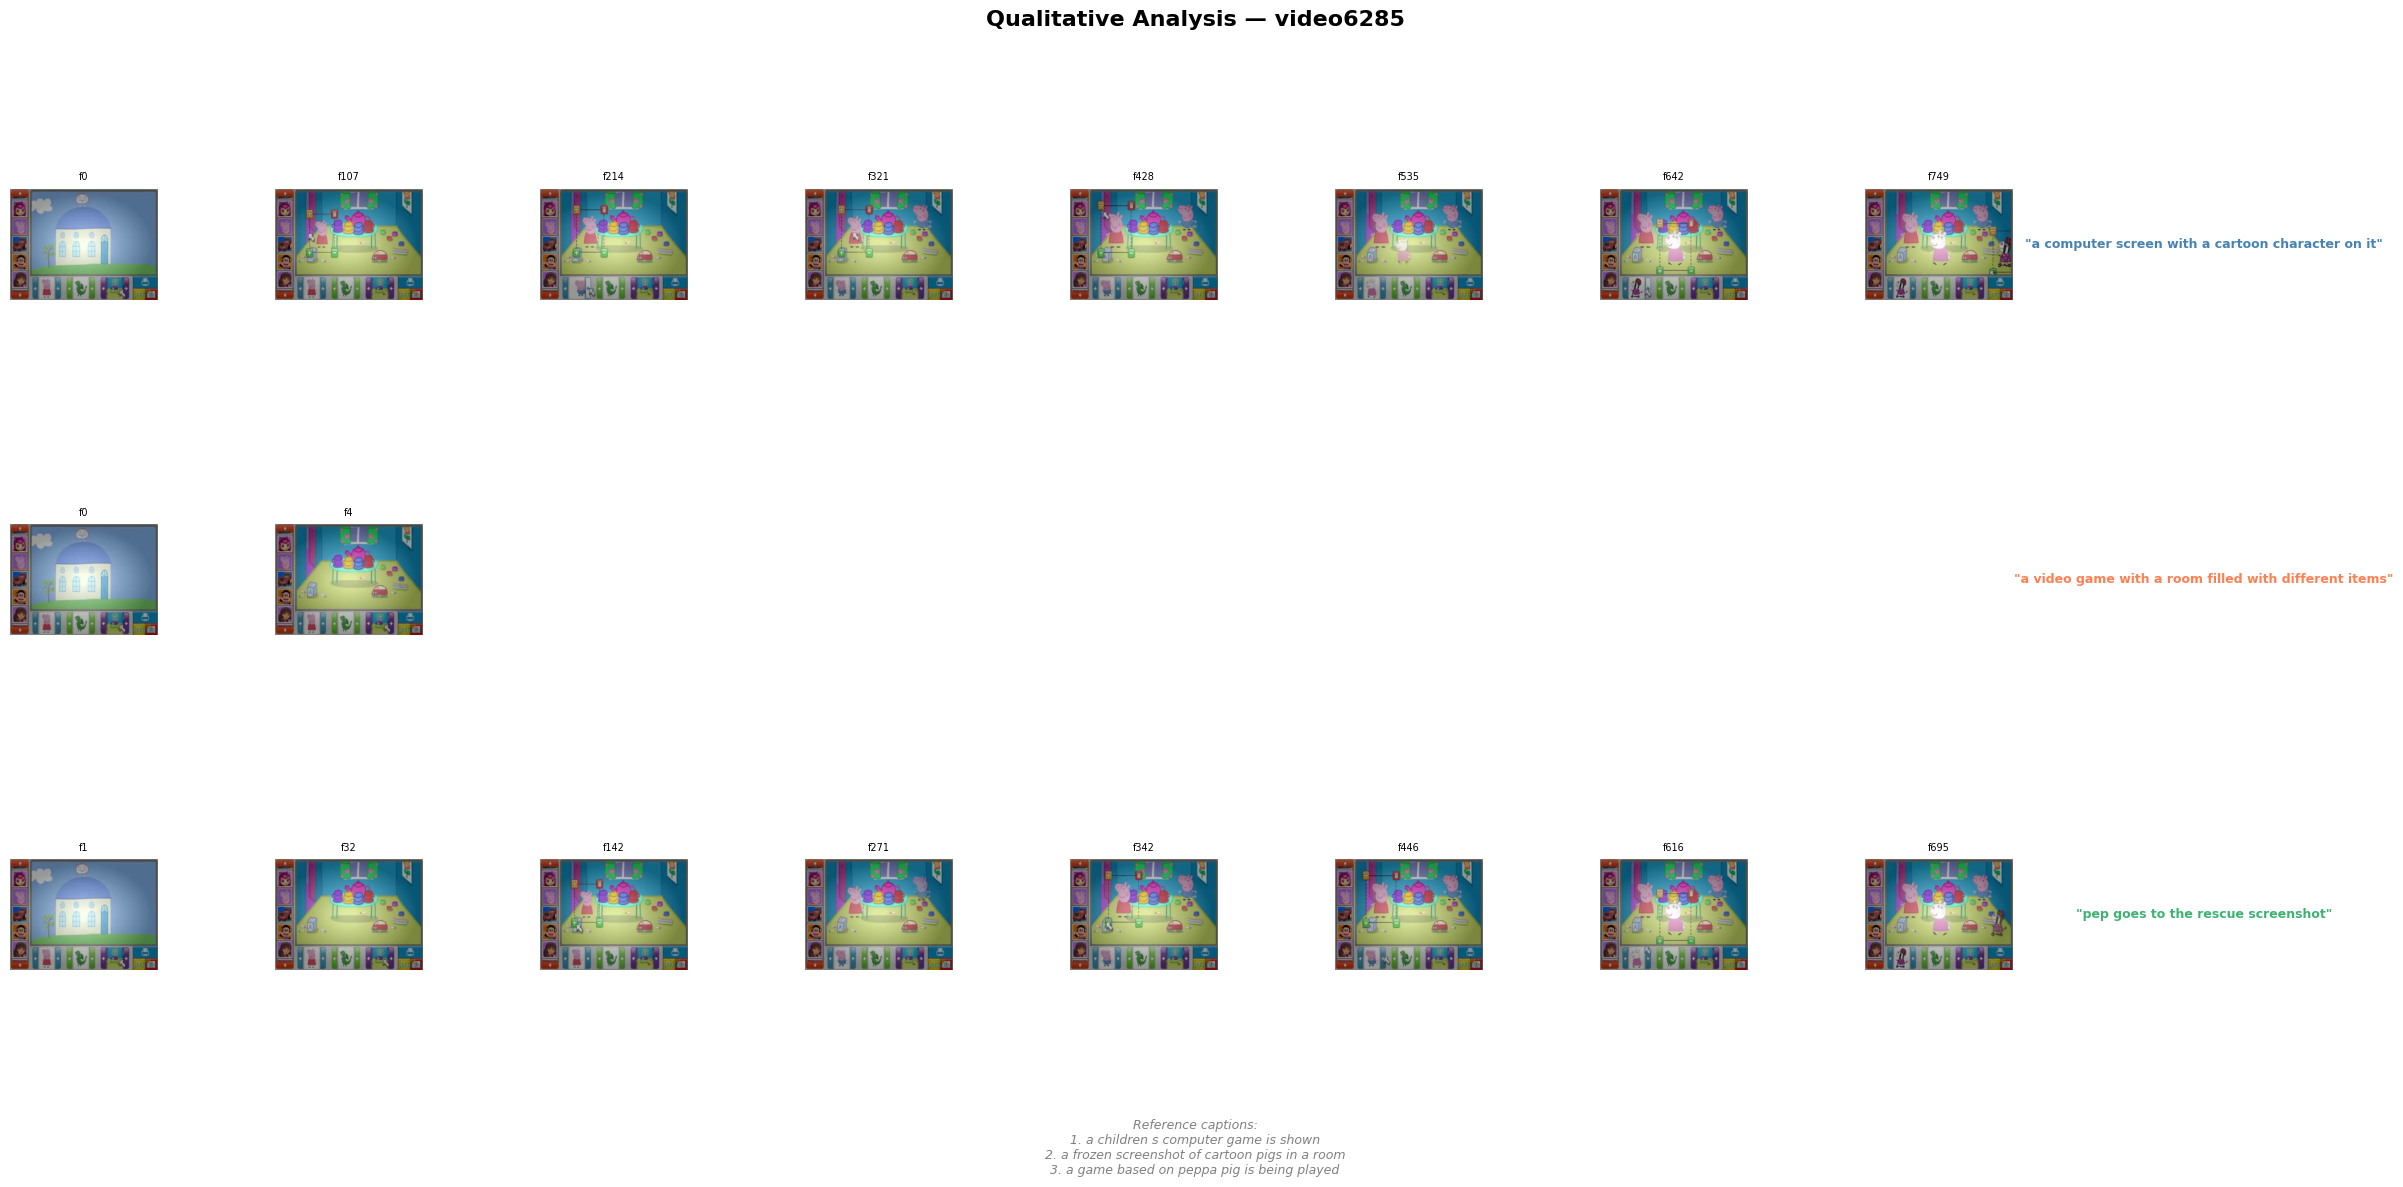

✅ video6285 saved!
Processing video4430...


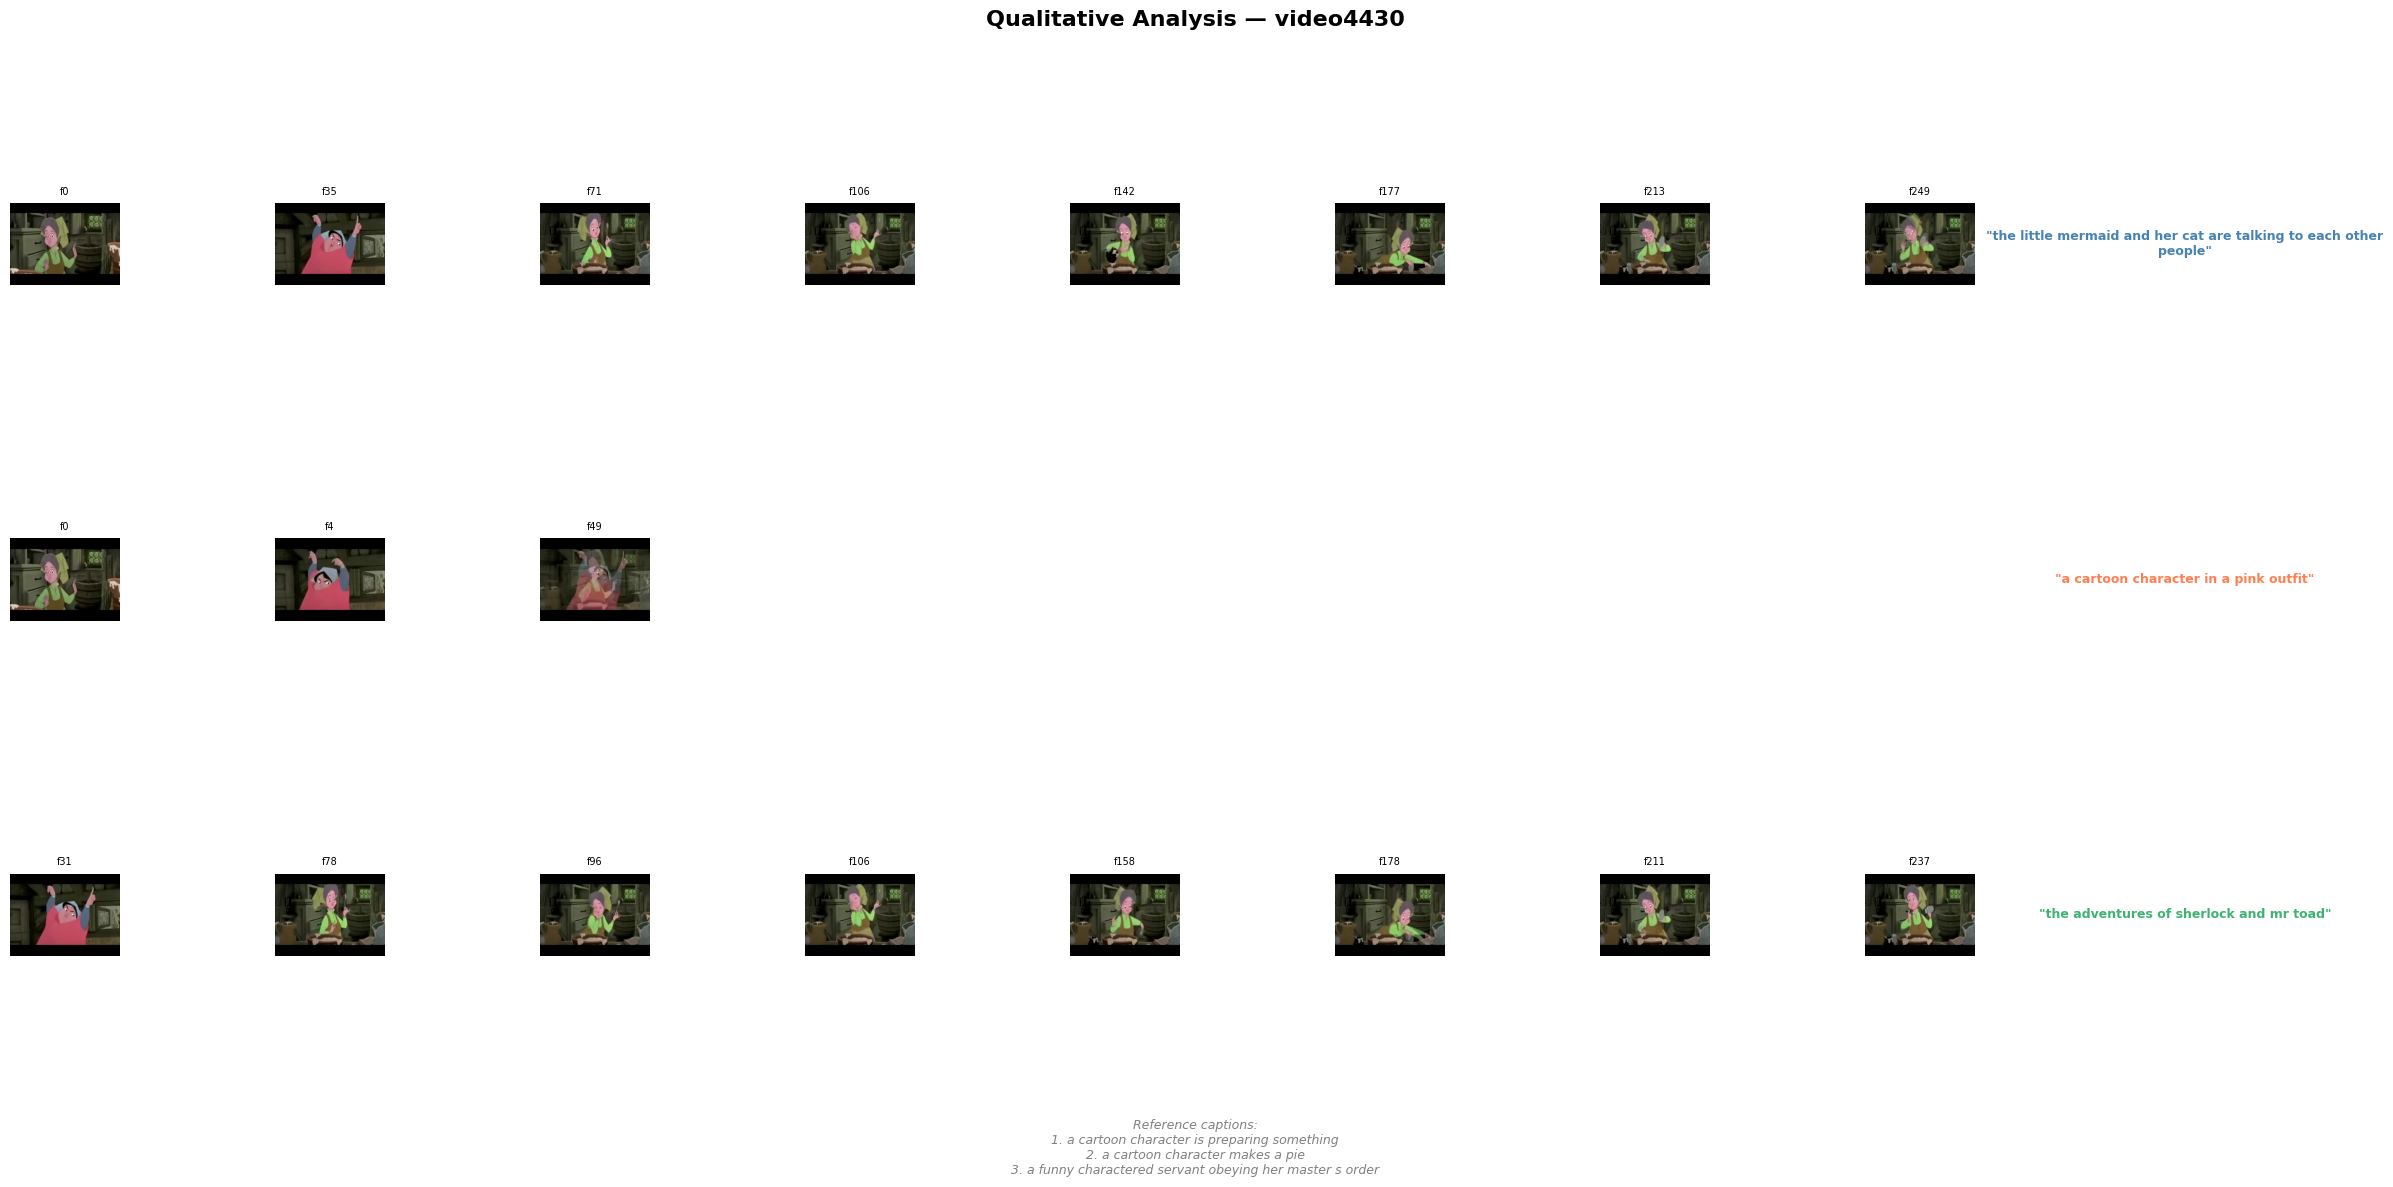

✅ video4430 saved!
Processing video5521...


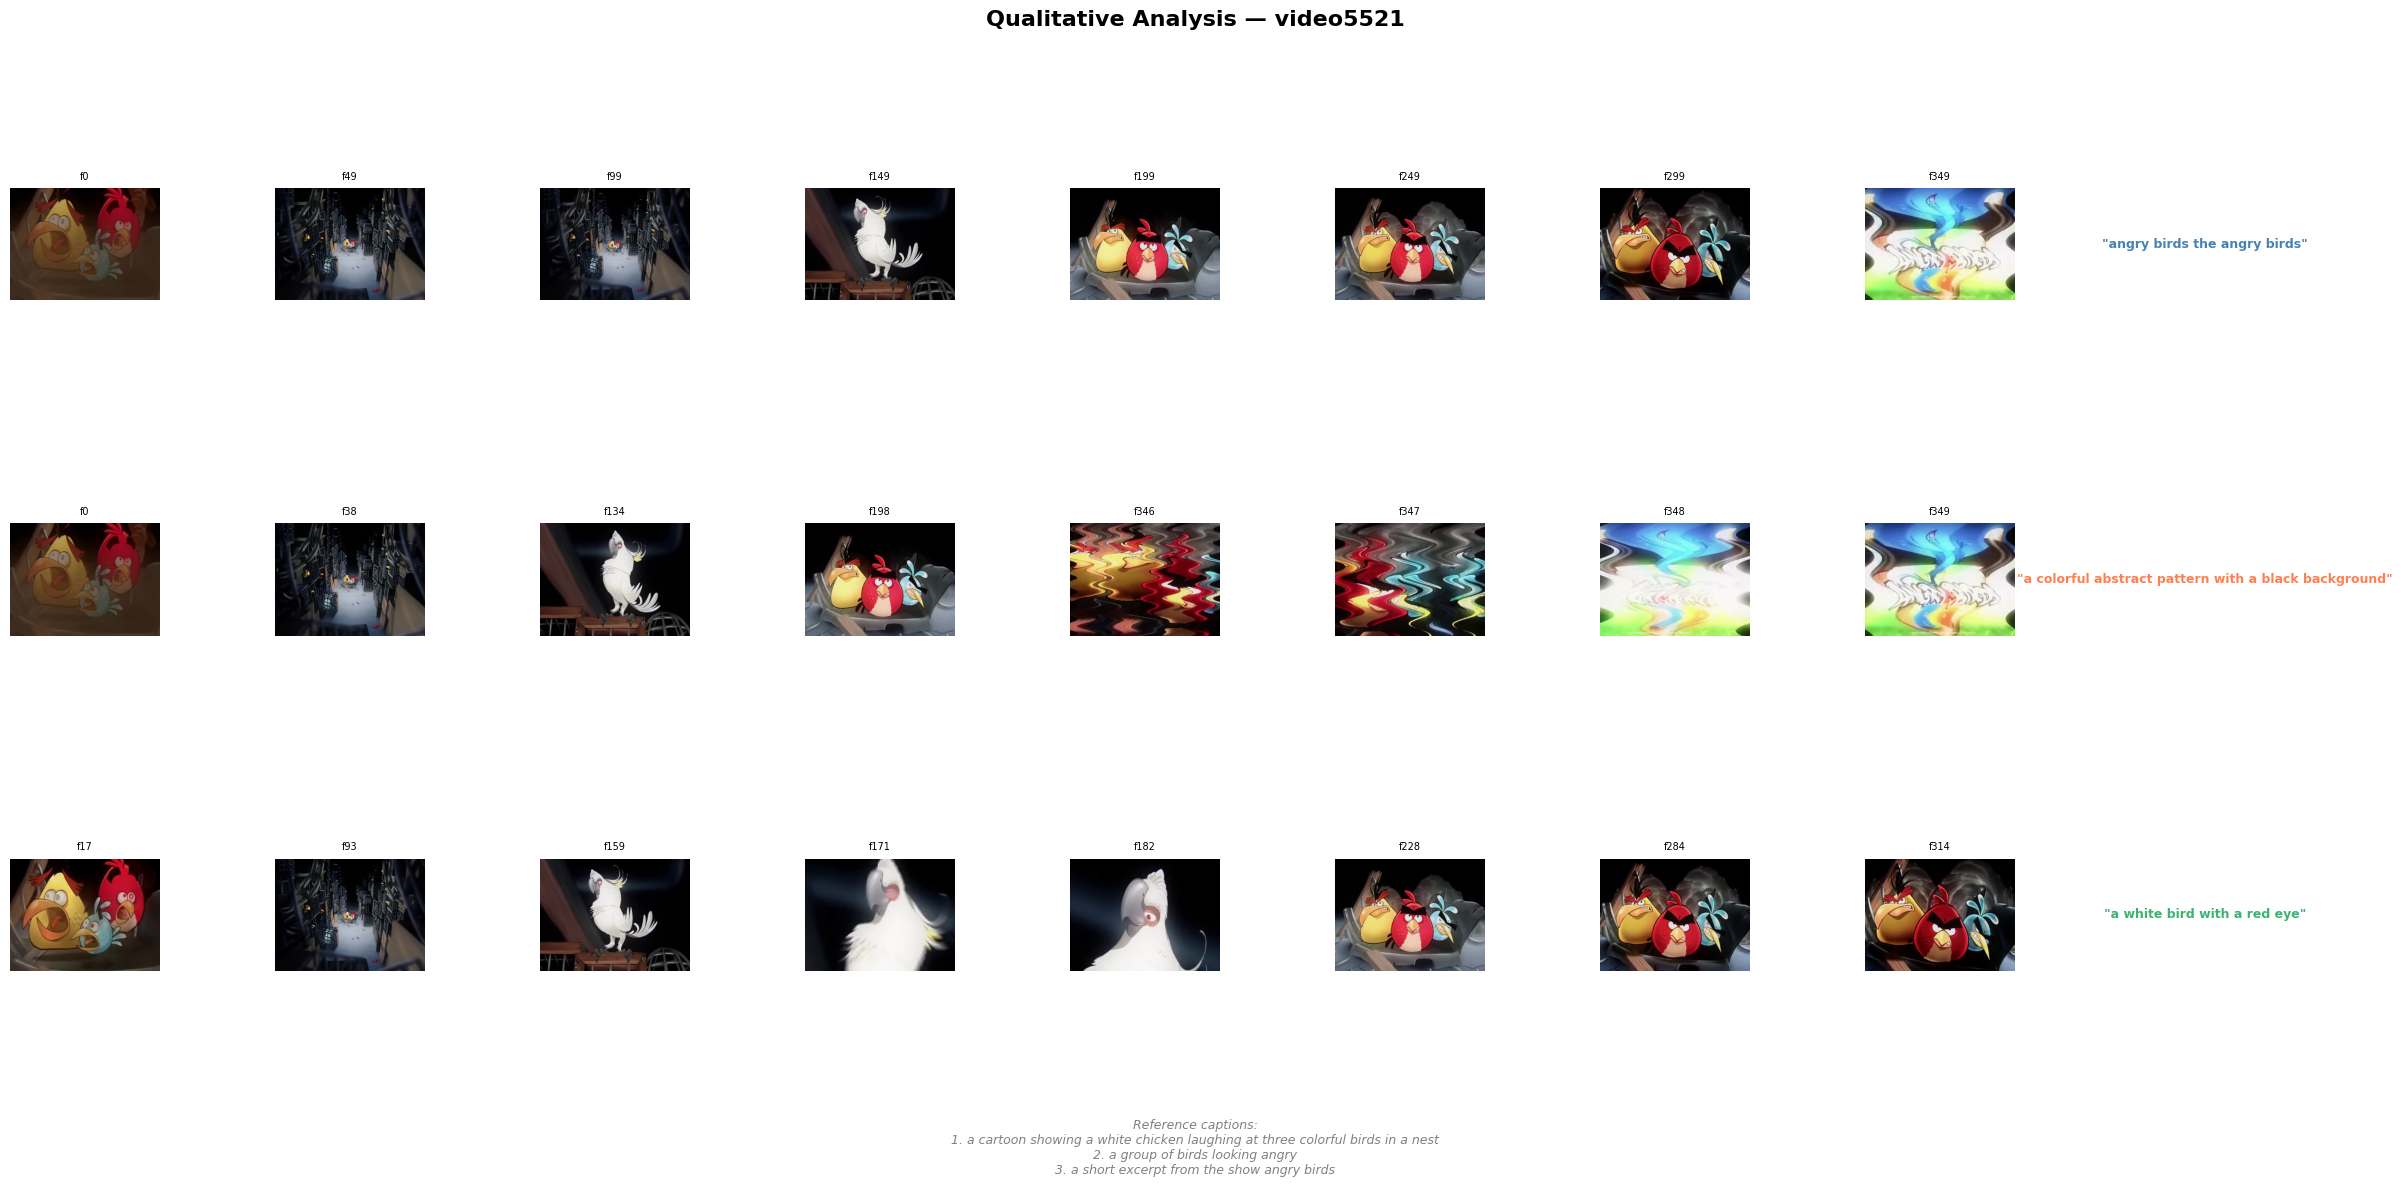

✅ video5521 saved!


In [15]:
from frame_extractor import extract_frames
from strategy_a_uniform import uniform_sampling
from strategy_b_ssim import ssim_sampling
from strategy_c_clip import load_clip_model, clip_kmeans_sampling
from blip_captioner import load_blip_model

load_blip_model()
load_clip_model()

output_dir = '/content/drive/MyDrive/thesis-data/figures/qualitative/'
os.makedirs(output_dir, exist_ok=True)

video_dir = '/content/drive/MyDrive/thesis-data/videos/'
selected_videos = ['video0', 'video6285', 'video4430', 'video5521']

for video_id in selected_videos:
    print(f"Processing {video_id}...")
    video_path = os.path.join(video_dir, f'{video_id}.mp4')
    frames, fps, total = extract_frames(video_path)

    fig = make_qualitative_figure(video_id, frames, ground_truth)

    save_path = os.path.join(output_dir, f'{video_id}_qualitative.png')
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()
    print(f"✅ {video_id} saved!")

In [17]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from frame_extractor import extract_frames
from strategy_a_uniform import uniform_sampling
from strategy_b_ssim import ssim_sampling
from strategy_c_clip import load_clip_model, clip_kmeans_sampling
from blip_captioner import load_blip_model

# Load models
load_blip_model()
load_clip_model()

output_dir = '/content/drive/MyDrive/thesis-data/figures/qualitative/'
os.makedirs(output_dir, exist_ok=True)

def make_qualitative_figure(video_id, frames, ground_truth):
    """
    Create a qualitative figure showing:
    - Keyframes from each strategy
    - Generated caption from each strategy
    - Reference captions from ground truth
    """
    # Get keyframes and captions
    a_indices = results_a[video_id]['keyframe_indices']
    a_caption = results_a[video_id]['caption']

    b_kf, b_indices, _ = ssim_sampling(frames, threshold=0.7)
    b_caption = results_b[video_id]['caption']

    c_kf, c_indices = clip_kmeans_sampling(frames, K=8)
    c_caption = results_c[video_id]['caption']

    # Get reference captions (first 3)
    refs = ground_truth.get(video_id, [])[:3]

    # Create figure
    fig = plt.figure(figsize=(24, 12))
    fig.patch.set_facecolor('white')

    # Title
    fig.suptitle(f'Qualitative Analysis — {video_id}',
                fontsize=16, fontweight='bold', y=0.98)

    strategies = [
        ('Strategy A (Uniform)', a_indices, 'steelblue', a_caption),
        ('Strategy B (SSIM)', b_indices, 'coral', b_caption),
        ('Strategy C (CLIP K-Means)', c_indices, 'mediumseagreen', c_caption),
    ]

    for row, (name, indices, color, caption) in enumerate(strategies):
        # Show up to 8 keyframes
        for col in range(8):
            ax = fig.add_subplot(3, 9, row*9 + col + 1)
            if col < len(indices):
                idx = indices[col]
                frame_rgb = cv2.cvtColor(frames[idx], cv2.COLOR_BGR2RGB)
                ax.imshow(frame_rgb)
                ax.set_title(f'f{idx}', fontsize=7)
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(name, fontsize=9, color=color,
                            fontweight='bold', rotation=90, labelpad=40)

        # Caption in last column
        ax_text = fig.add_subplot(3, 9, row*9 + 9)
        ax_text.axis('off')
        ax_text.text(0.5, 0.5, f'"{caption}"',
                    ha='center', va='center', fontsize=9,
                    color=color, fontweight='bold',
                    wrap=True, transform=ax_text.transAxes)

    # Add reference captions at bottom
    ref_text = "Reference captions:\n" + "\n".join([f"{i+1}. {r}" for i, r in enumerate(refs)])
    fig.text(0.5, 0.01, ref_text, ha='center', fontsize=9,
             style='italic', color='gray')

    plt.tight_layout(rect=[0, 0.08, 1, 0.96])
    return fig


# Generate figures for selected videos
# Pick 3 where A wins + 2 where C beats A
selected_videos = (
    [v for v, _, _, _ in a_beats_all[:3]] +
    [v for v, _, _, _ in c_beats_a[:2]]
)

video_dir = '/content/drive/MyDrive/thesis-data/videos/'

for video_id in selected_videos:
    print(f"Processing {video_id}...")
    video_path = os.path.join(video_dir, f'{video_id}.mp4')
    frames, fps, total = extract_frames(video_path)

    fig = make_qualitative_figure(video_id, frames, ground_truth)

    save_path = os.path.join(output_dir, f'{video_id}_qualitative.png')
    fig.savefig(save_path, dpi=150, bbox_inches='tight',
                facecolor='white')
    plt.show()
    plt.close()
    print(f"✅ {video_id} saved!")

Final Summary Figure

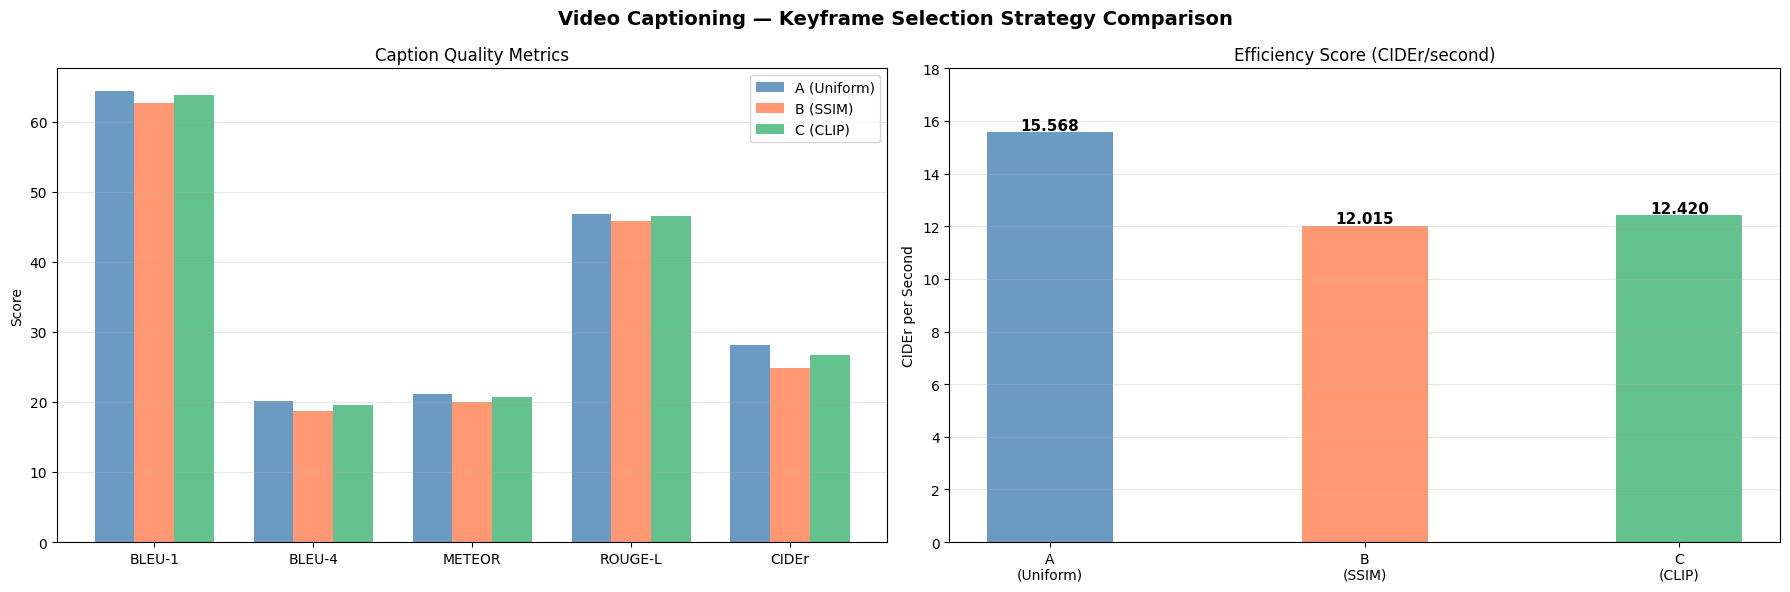

Final summary figure saved!


In [18]:
# Create a single summary figure combining all key results
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Video Captioning — Keyframe Selection Strategy Comparison',
             fontsize=14, fontweight='bold')

# Plot 1 — Main metrics comparison
metrics = ['BLEU-1', 'BLEU-4', 'METEOR', 'ROUGE-L', 'CIDEr']
x = np.arange(len(metrics))
width = 0.25

scores_data = {
    'Strategy_A': [64.38, 20.14, 21.10, 46.85, 28.07],
    'Strategy_B': [62.69, 18.77, 20.01, 45.76, 24.81],
    'Strategy_C': [63.80, 19.62, 20.76, 46.50, 26.74]
}

axes[0].bar(x - width, scores_data['Strategy_A'], width,
            label='A (Uniform)', color='steelblue', alpha=0.8)
axes[0].bar(x, scores_data['Strategy_B'], width,
            label='B (SSIM)', color='coral', alpha=0.8)
axes[0].bar(x + width, scores_data['Strategy_C'], width,
            label='C (CLIP)', color='mediumseagreen', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score')
axes[0].set_title('Caption Quality Metrics')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2 — Efficiency comparison
strategy_labels = ['A\n(Uniform)', 'B\n(SSIM)', 'C\n(CLIP)']
efficiency_scores = [15.568, 12.015, 12.420]
colors = ['steelblue', 'coral', 'mediumseagreen']

bars = axes[1].bar(strategy_labels, efficiency_scores,
                   color=colors, alpha=0.8, width=0.4)
for bar, val in zip(bars, efficiency_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{val:.3f}', ha='center', fontsize=11,
                fontweight='bold')
axes[1].set_ylabel('CIDEr per Second')
axes[1].set_title('Efficiency Score (CIDEr/second)')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 18)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis-data/figures/final_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Final summary figure saved!")

Complete Figures Inventory

In [19]:
print("\n COMPLETE FIGURES INVENTORY FOR THESIS")
print("=" * 60)

figures_dir = '/content/drive/MyDrive/thesis-data/figures/'
for root, dirs, files in os.walk(figures_dir):
    level = root.replace(figures_dir, '').count(os.sep)
    indent = '  ' * level
    folder = os.path.basename(root)
    if level == 0:
        print(f"figures/")
    else:
        print(f"{indent}{folder}/")
    for f in files:
        size = os.path.getsize(os.path.join(root, f)) / 1024
        print(f"{indent}  {f} ({size:.0f} KB)")


 COMPLETE FIGURES INVENTORY FOR THESIS
figures/
  evaluation_results.png (63 KB)
  speed_vs_quality.png (221 KB)
  final_summary.png (82 KB)
figures/
  video0_ABC_comparison.png (3619 KB)
  video1_ABC_comparison.png (3380 KB)
  video2_ABC_comparison.png (4080 KB)
  video3_ABC_comparison.png (1759 KB)
  video4_ABC_comparison.png (2729 KB)
  video5_ABC_comparison.png (4169 KB)
  video0_AB_comparison.png (1883 KB)
  video1_AB_comparison.png (1732 KB)
  video2_AB_comparison.png (2009 KB)
  video3_AB_comparison.png (778 KB)
  video4_AB_comparison.png (1416 KB)
  video5_AB_comparison.png (2101 KB)
figures/
  video0_qualitative.png (2478 KB)
  video6285_qualitative.png (1034 KB)
  video4430_qualitative.png (594 KB)
  video5521_qualitative.png (1456 KB)
